<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L10-Modelos_VAR/notebooks/L10_1_ModelosVAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR

In [2]:
# La función adfuller tiene una salida en forma de tupla
# Esta función genera una impresión del resumen
def pruebaDFA(serie, nombre, alpha = 0.05):
    result = adfuller(serie)
    print(f'--- Prueba de Dickey-Fuller Aumentada para {nombre} ---')
    print(f'H0: Serie No Estacionaria (Existe Raíz Unitaria)')
    print(f'H1: Serie Estacionaria (No existe Raíz Unitaria)\n')

    print(f'Estadístico ADF: {result[0]:.4f}') # Si el estadístico es menor (más negativo) que algún valor crítico se rechaza H0
    print(f'p-value: {result[1]:.4f}')
    print('Valores Críticos:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    if result[1] <= alpha:
        print(f'Conclusión: {nombre} es estacionaria. (Se rechaza Hipótesis Nula)\n')
    else:
        print(f'Conclusión: {nombre} no es estacionaria. (No se rechaza Hipótesis Nula)\n')

In [3]:
# Subir archivo google_bitcoin.csv
from google.colab import files
files.upload()

Saving google_bitcoin.csv to google_bitcoin (1).csv


{'google_bitcoin (1).csv': b'Date,google,bitcoin\r\n2020-01-05,36,7347.89\r\n2020-01-12,36,8021.49\r\n2020-01-19,32,8910.85\r\n2020-01-26,34,8327.36\r\n2020-02-02,36,9378.09\r\n2020-02-09,42,9907.12\r\n2020-02-16,36,9904.17\r\n2020-02-23,38,9669.63\r\n2020-03-01,34,8534.17\r\n2020-03-08,62,8898.63\r\n2020-03-15,66,5166.26\r\n2020-03-22,48,6189.85\r\n2020-03-29,40,6260.95\r\n2020-04-05,42,6871.69\r\n2020-04-12,40,6891.6\r\n2020-04-19,40,7259.36\r\n2020-04-26,52,7549.52\r\n2020-05-03,58,8973.82\r\n2020-05-10,66,9527.39\r\n2020-05-17,46,9385.7\r\n2020-05-24,42,9178.32\r\n2020-05-31,42,9698.1\r\n2020-06-07,38,9670.43\r\n2020-06-14,36,9473.5\r\n2020-06-21,34,9357.43\r\n2020-06-28,34,9004.23\r\n2020-07-05,32,9131.31\r\n2020-07-12,36,9235.96\r\n2020-07-19,34,9174.71\r\n2020-07-26,56,9707.5\r\n2020-08-02,50,11823.69\r\n2020-08-09,44,11767.6\r\n2020-08-16,44,11873.98\r\n2020-08-23,38,11683.44\r\n2020-08-30,40,11481.64\r\n2020-09-06,36,10159.62\r\n2020-09-13,34,10446.44\r\n2020-09-20,32,11081.43

In [4]:
df = pd.read_csv('google_bitcoin.csv')
display(df.head())

,Date,google,bitcoin
0,2020-01-05,36,7347.89
1,2020-01-12,36,8021.49
2,2020-01-19,32,8910.85
3,2020-01-26,34,8327.36
4,2020-02-02,36,9378.09


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df.index.name = 'Fecha'
display(df.head())

,google,bitcoin
Fecha,,
2020-01-05,36,7347.89
2020-01-12,36,8021.49
2020-01-19,32,8910.85
2020-01-26,34,8327.36
2020-02-02,36,9378.09


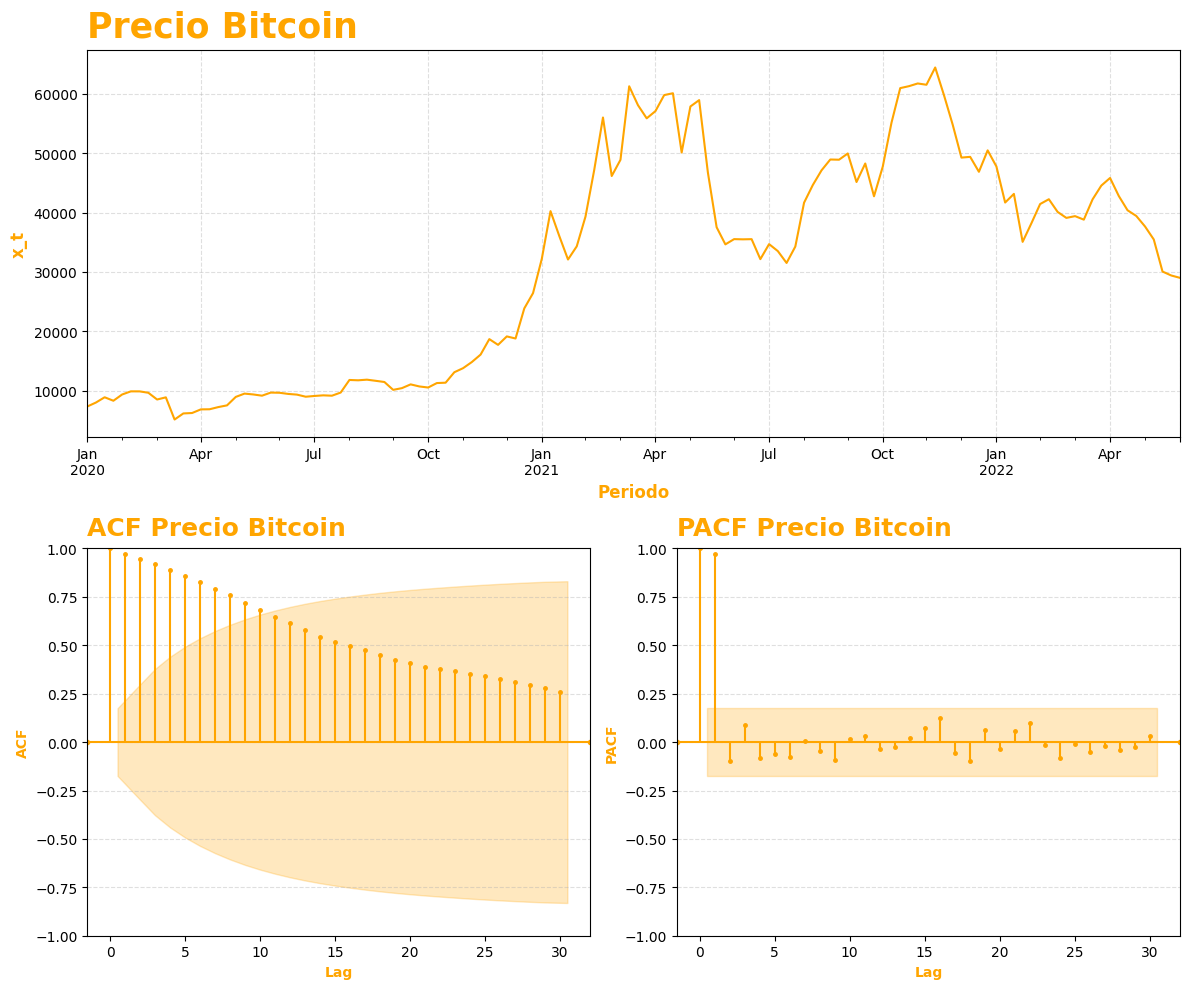

In [6]:
graphColor = 'orange'
columna = 'bitcoin'
nombre = 'Precio Bitcoin'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

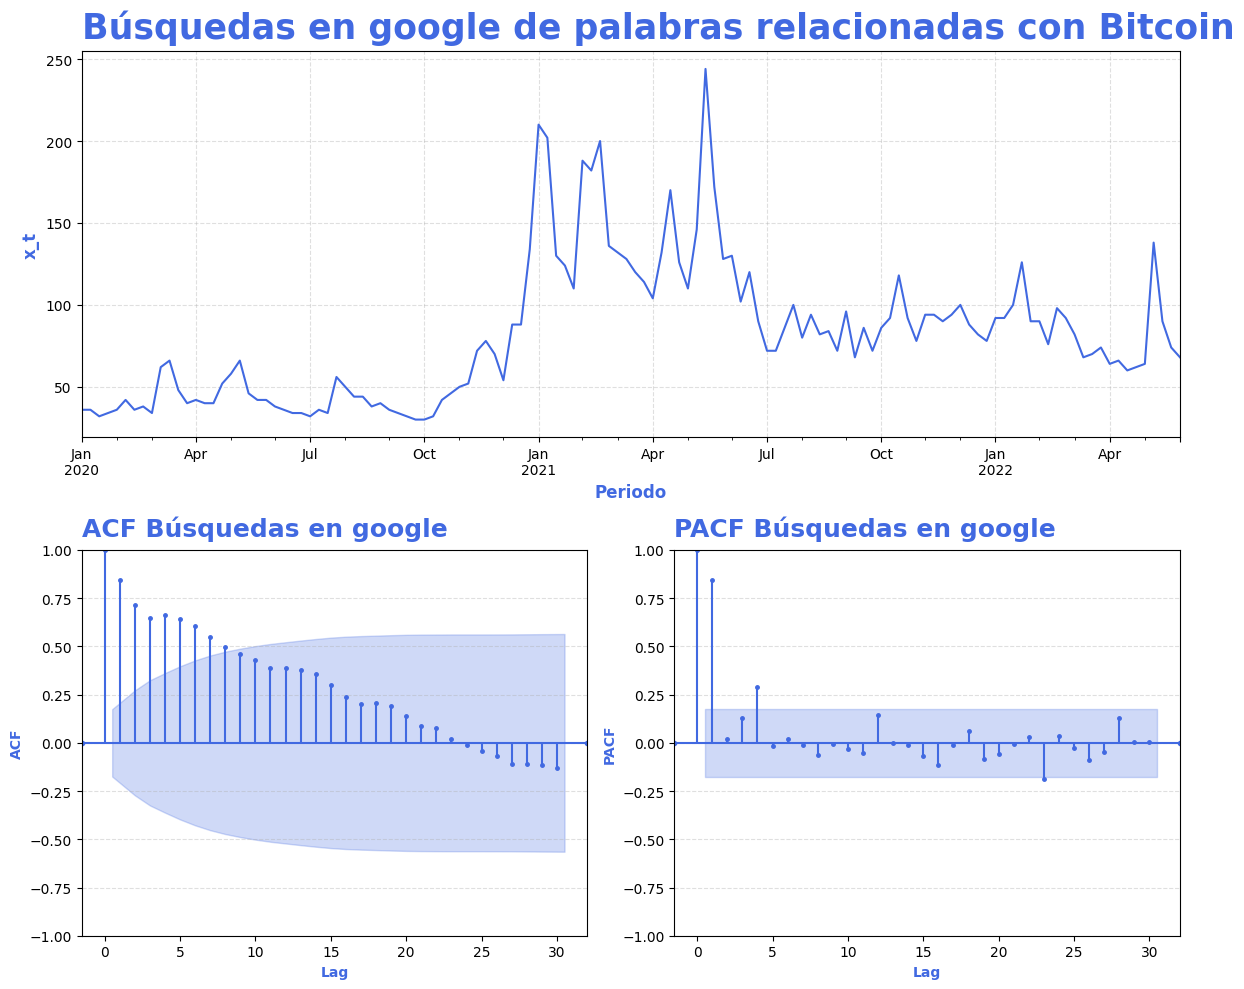

In [7]:
graphColor = 'royalblue'
columna = 'google'
nombre = 'Búsquedas en google de palabras relacionadas con Bitcoin'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF Búsquedas en google', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF Búsquedas en google', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

In [8]:
# Revisando estacionariedad
pruebaDFA(df['bitcoin'], 'Precio Bitcoin')
pruebaDFA(df['google'], 'Búsquedas en google de palabras relacionadas con Bitcoin')

--- Prueba de Dickey-Fuller Aumentada para Precio Bitcoin ---
H0: Serie No Estacionaria (Existe Raíz Unitaria)
H1: Serie Estacionaria (No existe Raíz Unitaria)

Estadístico ADF: -1.4723
p-value: 0.5472
Valores Críticos:
   1%: -3.4838
   5%: -2.8850
   10%: -2.5793
Conclusión: Precio Bitcoin no es estacionaria. (No se rechaza Hipótesis Nula)

--- Prueba de Dickey-Fuller Aumentada para Búsquedas en google de palabras relacionadas con Bitcoin ---
H0: Serie No Estacionaria (Existe Raíz Unitaria)
H1: Serie Estacionaria (No existe Raíz Unitaria)

Estadístico ADF: -1.9537
p-value: 0.3072
Valores Críticos:
   1%: -3.4851
   5%: -2.8855
   10%: -2.5796
Conclusión: Búsquedas en google de palabras relacionadas con Bitcoin no es estacionaria. (No se rechaza Hipótesis Nula)



In [9]:
# Revisando estacionariedad de las diferencias
df['bitcoin_diff'] = df['bitcoin'].diff()
df['google_diff'] = df['google'].diff()

pruebaDFA(df['bitcoin_diff'].dropna(), 'Precio Bitcoin Diferenciada')
pruebaDFA(df['google_diff'].dropna(), 'Búsquedas en google Diferenciada')

--- Prueba de Dickey-Fuller Aumentada para Precio Bitcoin Diferenciada ---
H0: Serie No Estacionaria (Existe Raíz Unitaria)
H1: Serie Estacionaria (No existe Raíz Unitaria)

Estadístico ADF: -8.2960
p-value: 0.0000
Valores Críticos:
   1%: -3.4847
   5%: -2.8853
   10%: -2.5795
Conclusión: Precio Bitcoin Diferenciada es estacionaria. (Se rechaza Hipótesis Nula)

--- Prueba de Dickey-Fuller Aumentada para Búsquedas en google Diferenciada ---
H0: Serie No Estacionaria (Existe Raíz Unitaria)
H1: Serie Estacionaria (No existe Raíz Unitaria)

Estadístico ADF: -10.2931
p-value: 0.0000
Valores Críticos:
   1%: -3.4851
   5%: -2.8855
   10%: -2.5796
Conclusión: Búsquedas en google Diferenciada es estacionaria. (Se rechaza Hipótesis Nula)



In [10]:
dfDiff = df[['bitcoin_diff', 'google_diff']].dropna()

# Inicializar el modelo VAR
modeloVAR = VAR(dfDiff)

# Seleccionar el orden de rezago óptimo (hasta un máximo de 5 rezagos)
# El método select_order devuelve un objeto LagOrderResults
selecLag = modeloVAR.select_order(maxlags=5)

print("Selección del Orden Óptimo de Rezago:")
print(selecLag.summary())

Selección del Orden Óptimo de Rezago:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       22.81      22.86*   8.058e+09      22.83*
1       22.81       22.95   8.035e+09       22.86
2       22.82       23.06   8.169e+09       22.92
3      22.71*       23.04  7.317e+09*       22.85
4       22.77       23.19   7.728e+09       22.94
5       22.80       23.31   7.961e+09       23.00
-------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


- Akaike Information Criterion (AIC) - Logverosimilitud con penalización
- Bayesian Information Criterion (BIC) *Schwarz criterion en multivariados* - Logverosimilitud con mayor penalización
- Final Prediction Error (FPE) criterion - Basado en RSS y penalización por parámetros
- Hannan–Quinn Information Criterion (HQC) - Logverosimilitud con penalización mayor a AIC pero menor a BIC.

In [11]:
lags = 3

# Ajustar el modelo VAR
modeloAjustado = modeloVAR.fit(lags)

print("Resumen del Modelo VAR Ajustado:")
print(modeloAjustado.summary())

Resumen del Modelo VAR Ajustado:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 03, Jul, 2026
Time:                     21:38:16
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    22.9992
Nobs:                     122.000    HQIC:                   22.8082
Log likelihood:          -1715.55    FPE:                7.06013e+09
AIC:                      22.6775    Det(Omega_mle):     6.31470e+09
--------------------------------------------------------------------
Results for equation bitcoin_diff
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                 162.319345       333.061750            0.487           0.626
L1.bitcoin_diff         0.174226         0.093425            1.865           0.062
L1.google_di

In [12]:
print("\n--- Prueba de Causalidad de Granger: bitcoin_diff en google_diff ---")
print("--- H0: bitcoin_diff NO causa google_diff en el sentido de Granger ---")
# La variable dependiente es google_diff. El orden de las columnas es importante: [dependiente, independiente]
grangerBitAGoog = grangercausalitytests(dfDiff[['google_diff', 'bitcoin_diff']], lags, verbose=True)


--- Prueba de Causalidad de Granger: bitcoin_diff en google_diff ---
--- H0: bitcoin_diff NO causa google_diff en el sentido de Granger ---

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=4.7607  , p=0.0310  , df_denom=121, df_num=1
ssr based chi2 test:   chi2=4.8788  , p=0.0272  , df=1
likelihood ratio test: chi2=4.7852  , p=0.0287  , df=1
parameter F test:         F=4.7607  , p=0.0310  , df_denom=121, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.0085  , p=0.1388  , df_denom=118, df_num=2
ssr based chi2 test:   chi2=4.1872  , p=0.1232  , df=2
likelihood ratio test: chi2=4.1175  , p=0.1276  , df=2
parameter F test:         F=2.0085  , p=0.1388  , df_denom=118, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.5766  , p=0.0572  , df_denom=115, df_num=3
ssr based chi2 test:   chi2=8.2003  , p=0.0420  , df=3
likelihood ratio test: chi2=7.9364  , p=0.0473  , df=3
parameter F test:         

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [13]:
print("\n--- Prueba de Causalidad de Granger: google_diff en bitcoin_diff ---")
print("--- H0: google_diff NO causa bitcoin_diff en el sentido de Granger ---")
# La variable dependiente es google_diff. El orden de las columnas es importante: [dependiente, independiente]
grangerGoogABit = grangercausalitytests(dfDiff[['bitcoin_diff', 'google_diff']], lags)


--- Prueba de Causalidad de Granger: google_diff en bitcoin_diff ---
--- H0: google_diff NO causa bitcoin_diff en el sentido de Granger ---

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.3034  , p=0.1317  , df_denom=121, df_num=1
ssr based chi2 test:   chi2=2.3606  , p=0.1244  , df=1
likelihood ratio test: chi2=2.3384  , p=0.1262  , df=1
parameter F test:         F=2.3034  , p=0.1317  , df_denom=121, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.8849  , p=0.4155  , df_denom=118, df_num=2
ssr based chi2 test:   chi2=1.8448  , p=0.3976  , df=2
likelihood ratio test: chi2=1.8311  , p=0.4003  , df=2
parameter F test:         F=0.8849  , p=0.4155  , df_denom=118, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.1936  , p=0.3154  , df_denom=115, df_num=3
ssr based chi2 test:   chi2=3.7989  , p=0.2840  , df=3
likelihood ratio test: chi2=3.7409  , p=0.2908  , df=3
parameter F test:         

In [14]:
print("Valor absoluto de los eigenvalores del modeloVAR:")
eigenVal = 1/abs(modeloAjustado.roots) # OJO!!!! "roots" devuelve las raíces inversas!!!!
print(eigenVal)

# Revisar estabilidad del modelo
if all(e <= 1 for e in eigenVal):
    print("\nEl modelo VAR es estable")
else:
    print("\nEl modelo VAR no es estable.")

Valor absoluto de los eigenvalores del modeloVAR:
[0.50057536 0.57172339 0.57172339 0.674652   0.73050529 0.73050529]

El modelo VAR es estable


In [15]:
# La prueba de Portmanteau (como la de Ljung-Box) verifica si los errores del modelo
# actúan como ruido blanco a través del tiempo y de las variables.

# H0: Los residuales son ruido blanco (no hay autocorrelación).
# H1: Los residuales no son ruido blanco (hay autocorrelación).

# test_whiteness usa el estadístico Q de Portmanteau (sigue una Xi-cuadrada) y el test de Ljung-Box.
portmanteau_test_results = modeloAjustado.test_whiteness(nlags=12)

print(portmanteau_test_results.summary())

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         34.70          51.00   0.531 36
----------------------------------------


In [16]:
# El método forecast necesita los últimos 'p' valores para iniciar el pronóstico
# Determinar el número de rezagos (p) utilizados en el modelo
p = modeloAjustado.k_ar
# Obtener las últimas 'p' observaciones de las series diferenciadas para el pronóstico
pObservaciones = dfDiff.tail(p)

# Generar el pronóstico a 15 pasos
pasos = 15
forecast_diff = modeloAjustado.forecast(y=pObservaciones.values, steps=pasos)
forecastDiff = pd.DataFrame(forecast_diff, columns = dfDiff.columns) # guardar en un df

# Incluir la última observación para poder dibujar una línea continua
forecastDiff = pd.concat([dfDiff.iloc[[-1]], forecastDiff])
fechaInicio = dfDiff.index[-1]
fechasForecast = pd.date_range(start=fechaInicio, periods=pasos + 1, freq='W-SUN') # pasos + 1 para incluir último valor
forecastDiff = forecastDiff.set_index(fechasForecast)

forecastDiff.head()

,bitcoin_diff,google_diff
2022-05-29,-396.230000,-6.000000
2022-06-05,660.453821,25.358858
2022-06-12,25.718145,2.839169
2022-06-19,57.557997,-2.683900
2022-06-26,-214.445681,-7.922468


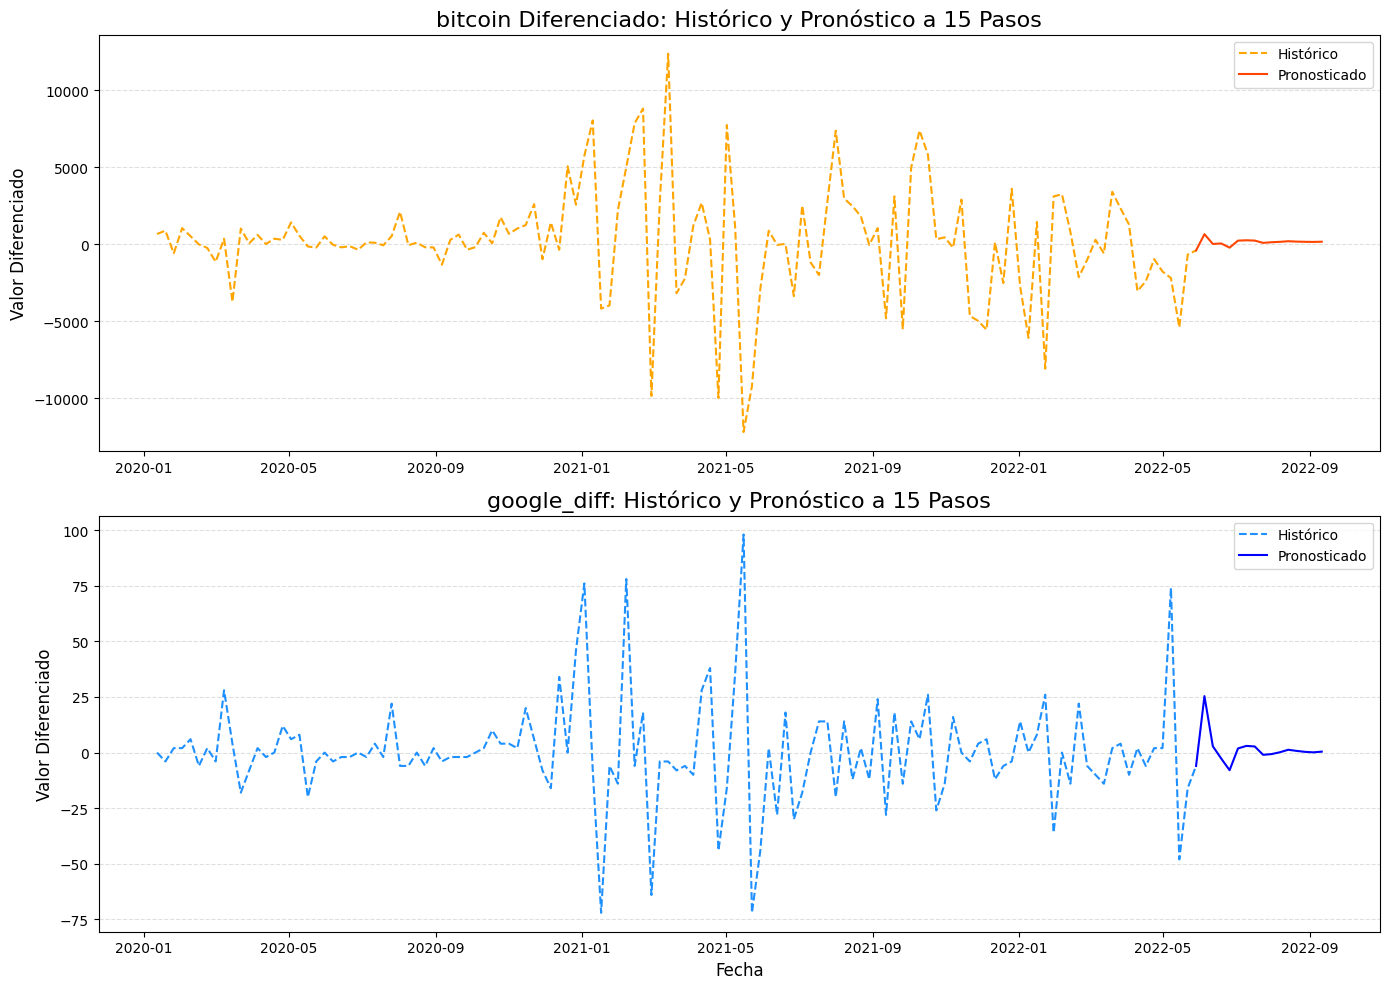

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

axes[0].plot(dfDiff['bitcoin_diff'], label='Histórico', color='orange', linestyle='--')
axes[0].plot(forecastDiff['bitcoin_diff'], label='Pronosticado', lw = 1.5, color='orangered')
axes[0].set_title('bitcoin Diferenciado: Histórico y Pronóstico a 15 Pasos', fontsize=16)
axes[0].set_ylabel('Valor Diferenciado', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].legend()

# Gráfico para google_diff
axes[1].plot(dfDiff['google_diff'], label='Histórico', color='dodgerblue', linestyle='--')
axes[1].plot(forecastDiff['google_diff'], label='Pronosticado', lw = 1.5, color='blue')
axes[1].set_title('google_diff: Histórico y Pronóstico a 15 Pasos', fontsize=16)
axes[1].set_xlabel('Fecha', fontsize=12)
axes[1].set_ylabel('Valor Diferenciado', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Obtener la última observación de las series originales
ultimoBitcoin = df['bitcoin'].iloc[-1]
ultimoGoogle = df['google'].iloc[-1]

# Inicializar listas para almacenar los pronósticos sin diferenciar
# Estas listas ya incluyen el último valor histórico como punto de partida
forecastBitcoin = [ultimoBitcoin]
forecastGoogle = [ultimoGoogle]

# Reconstruir las series originales a partir de los pronósticos diferenciados
# Iteramos sobre todos los pronósticos diferenciados que ya incluyen el último valor histórico
for i in range(1, pasos + 1):
    # Bitcoin
    nuevoBitcoin = forecastBitcoin[-1] + forecastDiff['bitcoin_diff'].iloc[i]
    forecastBitcoin.append(nuevoBitcoin)

    # Google
    nuevoGoogle = forecastGoogle[-1] + forecastDiff['google_diff'].iloc[i]
    forecastGoogle.append(nuevoGoogle)

# Crear un DataFrame con los pronósticos en la escala original
# Ahora incluimos todos los valores, desde la última observación histórica hasta el final del pronóstico
forecastOriginal = pd.DataFrame({
    'bitcoin_original_forecast': forecastBitcoin,
    'google_original_forecast': forecastGoogle
}, index=forecastDiff.index)

forecastOriginal.head()

,bitcoin_original_forecast,google_original_forecast
2022-05-29,29013.690000,68.000000
2022-06-05,29674.143821,93.358858
2022-06-12,29699.861965,96.198027
2022-06-19,29757.419963,93.514127
2022-06-26,29542.974281,85.591659


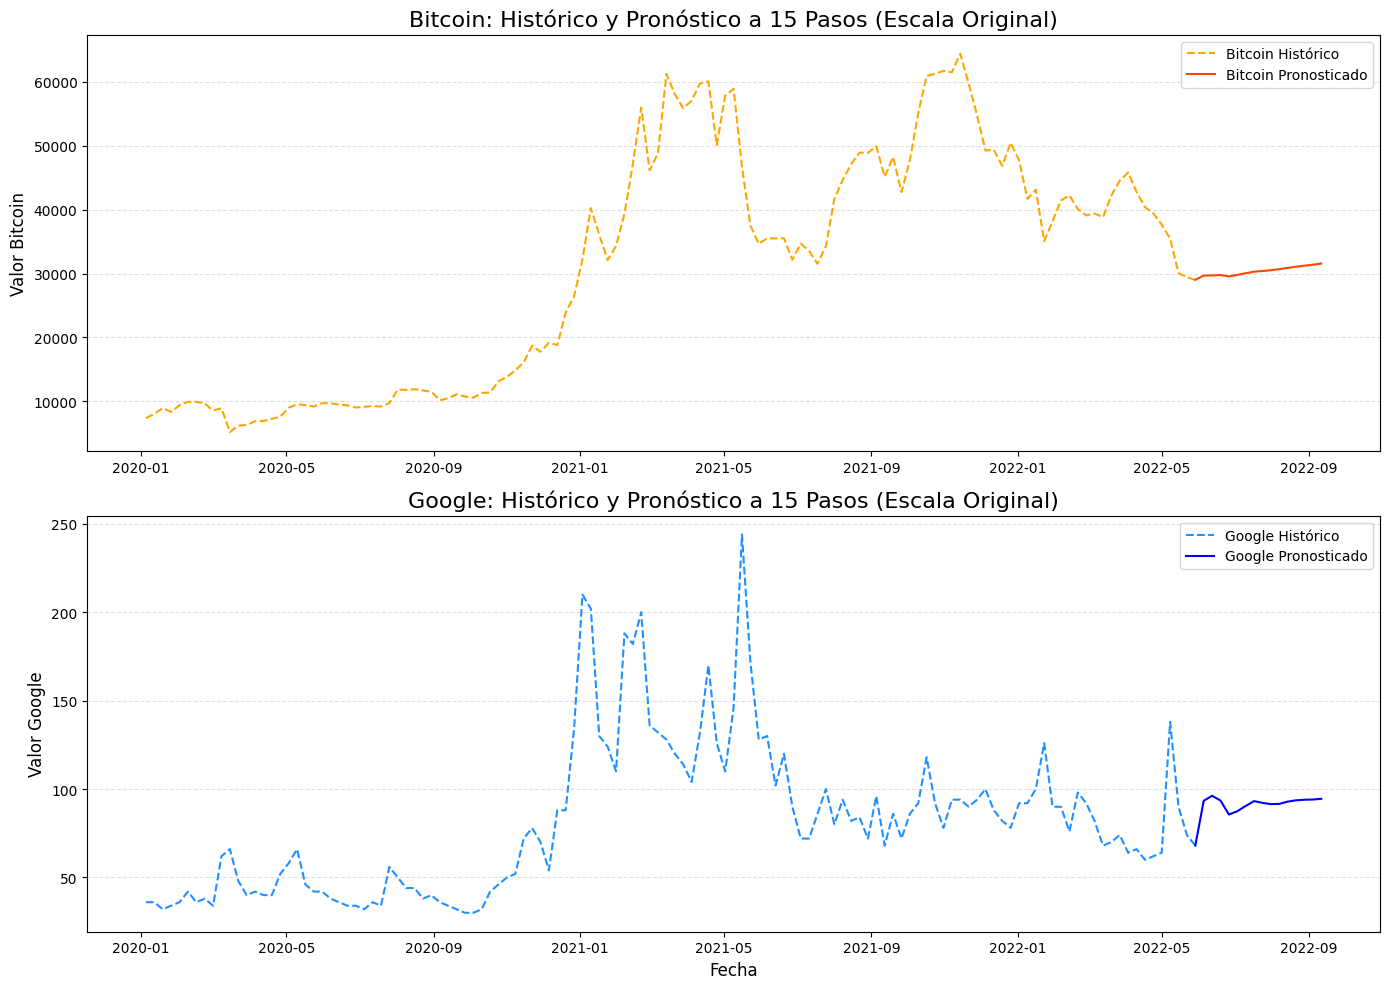

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Gráfico para Bitcoin original y su pronóstico
axes[0].plot(df['bitcoin'], label='Bitcoin Histórico', color='orange', linestyle='--')
axes[0].plot(forecastOriginal['bitcoin_original_forecast'], label='Bitcoin Pronosticado', lw = 1.5, color='orangered')
axes[0].set_title('Bitcoin: Histórico y Pronóstico a 15 Pasos (Escala Original)', fontsize=16)
axes[0].set_ylabel('Valor Bitcoin', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].legend()

# Gráfico para Google original y su pronóstico
axes[1].plot(df['google'], label='Google Histórico', color='dodgerblue', linestyle='--')
axes[1].plot(forecastOriginal['google_original_forecast'], label='Google Pronosticado', lw = 1.5, color='blue')
axes[1].set_title('Google: Histórico y Pronóstico a 15 Pasos (Escala Original)', fontsize=16)
axes[1].set_xlabel('Fecha', fontsize=12)
axes[1].set_ylabel('Valor Google', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()